ML Lab - 8


Example 1: SGD in MLP

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


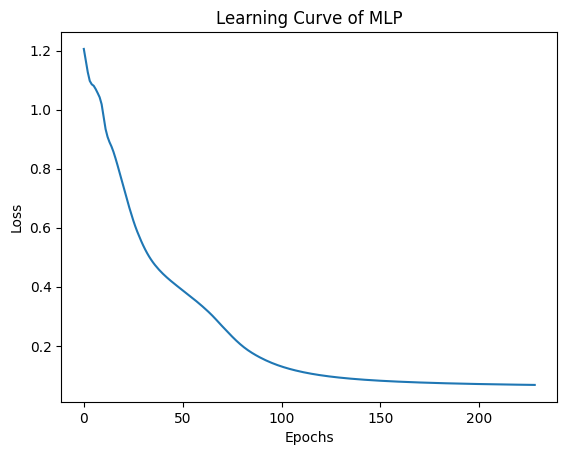

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlp_sgd = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    momentum=0.9,
    max_iter=500,
    random_state=42
)
mlp_sgd.fit(X_train, y_train)
y_pred = mlp_sgd.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
plt.plot(mlp_sgd.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Learning Curve of MLP")
plt.show()

Example 2: Hyperparameter Tuning

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    momentum=0.9,
    max_iter=500,
    random_state=42
)
param_grid = {
'hidden_layer_sizes': [(10,), (20,), (10,10)],
'activation': ['relu', 'tanh'],
'learning_rate_init': [0.001, 0.01],
'alpha': [0.0001, 0.001]
}
grid = GridSearchCV(mlp, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (10,), 'learning_rate_init': 0.001}
Best Score: 0.975


Example 3: SVM for Classification (Linear Kernel)

In [5]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Number of Support Vectors: [ 3 11 11]
Weights (w): [[-0.04631136  0.52105578 -1.0030165  -0.46411816]
 [-0.00641373  0.17867392 -0.5389119  -0.29158729]
 [ 0.56766907  1.21519237 -2.03626115 -1.70330734]]
Bias (b): [1.45338269 1.50537328 5.8028791 ]


Exercise 1: Identify the hyper parameters for Wisconsin dataset

In [6]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm = SVC()
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.001]
}
grid = GridSearchCV(svm, param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Best Hyperparameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Hyperparameters: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy: 0.956140350877193


In [8]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlp = MLPClassifier(
    solver='adam',
    max_iter=3000,
    random_state=42
)
param_grid = {
    'hidden_layer_sizes': [(20,), (50,), (30,30)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}
grid = GridSearchCV(mlp, param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Breast Cancer Dataset")
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Breast Cancer Dataset
Best Parameters: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}
Best CV Score: 0.9516483516483516
Test Accuracy: 0.9649122807017544


Exercise 2: Identify the hyper parameters for Indian diabetes dataset

In [20]:
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Path to dataset files:", path)

100%|██████████| 8.91k/8.91k [00:00<00:00, 12.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
df = pd.read_csv("D:\\VIT Chennai\\sem 6\\ML\\datasets\\diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svm = SVC()
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01]
}
grid = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Best Hyperparameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Hyperparameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.7337662337662337


In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
df = pd.read_csv("D:\\VIT Chennai\\sem 6\\ML\\datasets\\diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
mlp = MLPClassifier(
    solver='adam',
    max_iter=1000,
    random_state=42
)
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (20,10)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001]
}
grid = GridSearchCV(
    mlp,
    param_grid,
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Diabetes Dataset")
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Diabetes Dataset
Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (20,), 'learning_rate_init': 0.001}
Best CV Score: 0.7736505397840864
Test Accuracy: 0.7532467532467533


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
df = pd.read_csv("D:\\VIT Chennai\\sem 6\\ML\\datasets\\diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm = SVC()
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.001]
}
grid = GridSearchCV(svm, param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Best Hyperparameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
df = pd.read_csv("D:\\VIT Chennai\\sem 6\\ML\\datasets\\diabetes.csv")
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mlp = MLPClassifier(
    solver='adam',
    max_iter=3000,
    random_state=42
)
param_grid = {
    'hidden_layer_sizes': [(10,), (20,), (20,10)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}
grid = GridSearchCV(mlp, param_grid, cv=5)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Diabetes Dataset")
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Exercise 3: Apply Linear SVM for classifiying Survived (0/1) in titanic dataset

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/content/Titanic-Dataset.csv")
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Titanic Dataset")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Titanic Dataset
Accuracy: 0.7821229050279329

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

Number of Support Vectors: [157 157]
Weights (w): [[-1.37116638e-03  2.00202119e+00 -1.20661465e-04 -4.58157218e-03
  -1.42138421e-03  7.77476875e-05]]
Bias (b): [-0.99510203]


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/content/Titanic-Dataset.csv")
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']]
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
X = df.drop("Survived", axis=1)
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Titanic Dataset")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Titanic Dataset
Accuracy: 0.776536312849162

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179

Number of Support Vectors: [164 158]
Weights (w): [[ 1.20633321e-04  9.57227840e-01 -1.13897483e-04 -1.52992117e-04
  -9.59287049e-05  1.26203038e-04]]
Bias (b): [-0.28918751]


Exercise 4: Apply Linear SVM for classifying (Benign / Malignant) in Wisconsin Dataset

In [11]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Breast Cancer Dataset")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Breast Cancer Dataset
Accuracy: 0.956140350877193

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Number of Support Vectors: [27 24]
Weights (w): [[ 1.25502362e+00  9.29619046e-02 -1.44014265e-01 -6.97860161e-04
  -2.56387414e-01 -2.80595775e-01 -6.75055359e-01 -3.99157939e-01
  -3.42945746e-01 -4.16351035e-02 -9.79384870e-02  1.60499599e+00
  -1.31056529e-02 -6.79865242e-02 -5.03740598e-02  6.08360489e-02
  -7.39855064e-02 -5.20313993e-02 -5.19898145e-02  1.66865008e-02
  -9.71381631e-02 -2.83227241e-01  1.91900038e-02 -5.57929558e-03
  -4.66965712e-01 -9.00305643e-01 -1.72490800e+00 -6.31042038e-01
  -1.19545791e+00 -1.24727547e-01]]
Bias (b): [7.76579003]


In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
print("Breast Cancer Dataset")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Number of Support Vectors:", svm_model.n_support_)
print("Weights (w):", svm_model.coef_)
print("Bias (b):", svm_model.intercept_)

Breast Cancer Dataset
Accuracy: 0.9736842105263158

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Number of Support Vectors: [15 17]
Weights (w): [[-0.46967401 -0.09483535 -0.47629349 -0.43457548  0.06854461  0.76125943
  -0.558681   -0.52421748 -0.07182003  0.05407305 -0.70877134  0.51107099
  -0.5848979  -0.79458777 -0.06954022  0.53115732  0.11050251 -0.52265762
   0.04867218  0.48469097 -0.56241404 -1.38522681 -0.58717915 -0.73418515
  -0.92930883  0.12200123 -0.68830494 -0.3619916  -0.53523531 -0.35589177]]
Bias (b): [0.04885359]
